In [2]:
# ============================================================
# Topic and Framing Analysis Visualisation
# Autonomous Vehicle Media Coverage Dissertation
# ============================================================


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [3]:
# ============================================================
# Load dataset
# ============================================================

DATA_PATH = Path(
    "/Users/yurujia/Desktop/Dissertation Data/final_AV_media_analysis_dataset.xlsx"
)


df = pd.read_excel(DATA_PATH)


print(df.shape)

df.head()

(1809, 12)


,title,source,date_fixed,year,month,analysis_text,topic,sentiment,country,year_month,source_id,sentiment_analysis_text
0,（财经）专访：“中德电动汽车合作远大于竞争”——访蔚来汽车董事长李斌,Xinhua,2017-06-02,2017,2017-06,在李克强总理访问德国期间，蔚来汽车５月３１日在柏林与德国大陆集团签署战略合作协议，主要涉及电...,Business and Commercialisation,1,China,NaN,NaN,NaN
1,（李克强出访配合稿）专访：务实合作始终是中德关系的基本特征——访中国驻德国公使衔参赞王卫东,Xinhua,2017-06-03,2017,2017-06,王卫东说，中德双方应“共塑创新”，构建双边关系发展新引擎。双方在智能制造、人工智能、自动驾驶...,Technology and Innovation,1,China,NaN,NaN,NaN
2,中国新能源汽车全球占比一半,Xinhua,2017-06-06,2017,2017-06,“我们正在逐渐把自动驾驶融入电动汽车这个重大专项、融入未来电动汽车产品当中。”万钢说。,Technology and Innovation,1,China,NaN,NaN,NaN
3,（科技）专家：自动驾驶技术有望让交通事故零伤亡,Xinhua,2017-06-07,2017,2017-06,吉利欧洲研发中心首席执行官方浩瀚日前在位于瑞典哥德堡的总部对新华社记者表示，未来汽车应用自动...,Safety and Risk,1,China,NaN,NaN,NaN
4,（财经）日本预计于２０２３年普及５Ｇ通信,Xinhua,2017-06-07,2017,2017-06,下一代超高速无线通信技术——第五代移动通信技术（５Ｇ）的商业使用区域预计将于２０２３年扩大至...,Technology and Innovation,1,China,NaN,NaN,NaN


In [4]:
# ============================================================
# Inspect topic categories
# ============================================================


print(df.columns.tolist())


print(
    df["topic"].value_counts()
)

['title', 'source', 'date_fixed', 'year', 'month', 'analysis_text', 'topic', 'sentiment', 'country', 'year_month', 'source_id', 'sentiment_analysis_text']
topic
Technology and Innovation         684
Business and Commercialisation    571
Policy and Regulation             182
Mobility and Social Impact        148
Safety and Risk                    83
Other                              56
Legal and Ethics                   43
Public Acceptance and Trust        30
Environment and Sustainability     12
Name: count, dtype: int64


In [5]:
# ============================================================
# Topic order
# ============================================================


topic_order = [
    "Technology and Innovation",
    "Safety and Risk",
    "Policy and Regulation",
    "Business and Commercialisation",
    "Public Acceptance and Trust",
    "Mobility and Social Impact",
    "Environment and Sustainability",
    "Legal and Ethics",
    "Other"
]


df["topic"] = pd.Categorical(
    df["topic"],
    categories=topic_order,
    ordered=True
)

In [6]:
# ============================================================
# Plot style
# ============================================================


plt.rcParams.update({

    "font.family": "Arial",
    "font.size": 11,
    "axes.titlesize": 13,
    "axes.labelsize": 11

})

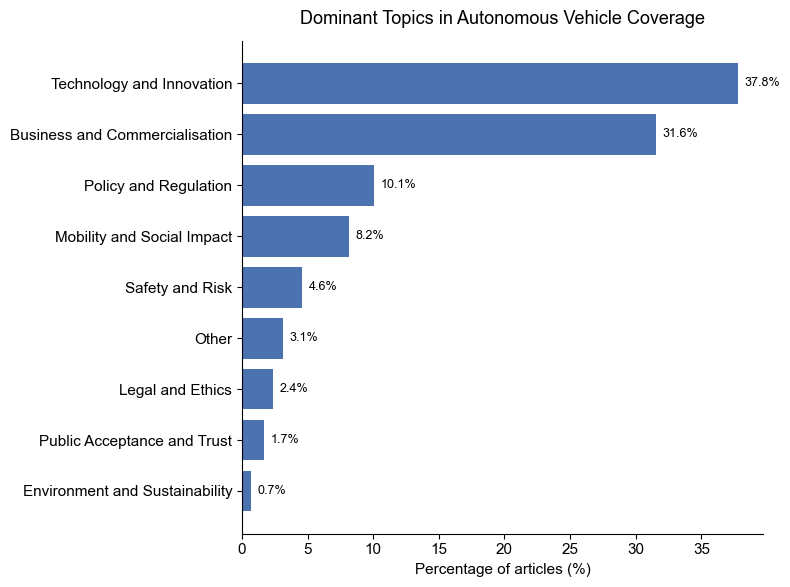

In [14]:
# ============================================================
# Figure 4
# Overall topic distribution (sorted)
# ============================================================


topic_counts = (
    df["topic"]
    .value_counts()
)


topic_percent = (
    topic_counts /
    topic_counts.sum()
    *100
)


topic_percent = (
    topic_percent
    .sort_values(ascending=True)
)



fig, ax = plt.subplots(
    figsize=(8,6)
)


ax.barh(
    topic_percent.index,
    topic_percent.values,
    color="#4C72B0"
)



ax.set_xlabel(
    "Percentage of articles (%)"
)


ax.set_ylabel("")


ax.set_title(
    "Dominant Topics in Autonomous Vehicle Coverage",
    pad=12
)



for i,value in enumerate(topic_percent):

    ax.text(
        value+0.5,
        i,
        f"{value:.1f}%",
        va="center",
        fontsize=9
    )



ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)



plt.tight_layout()



plt.savefig(
    "Figure4_topic_distribution_sorted.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

/var/folders/b6/85x24w2d4ylbyt_d01shhwfh0000gn/T/ipykernel_73508/2878820143.py:15: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


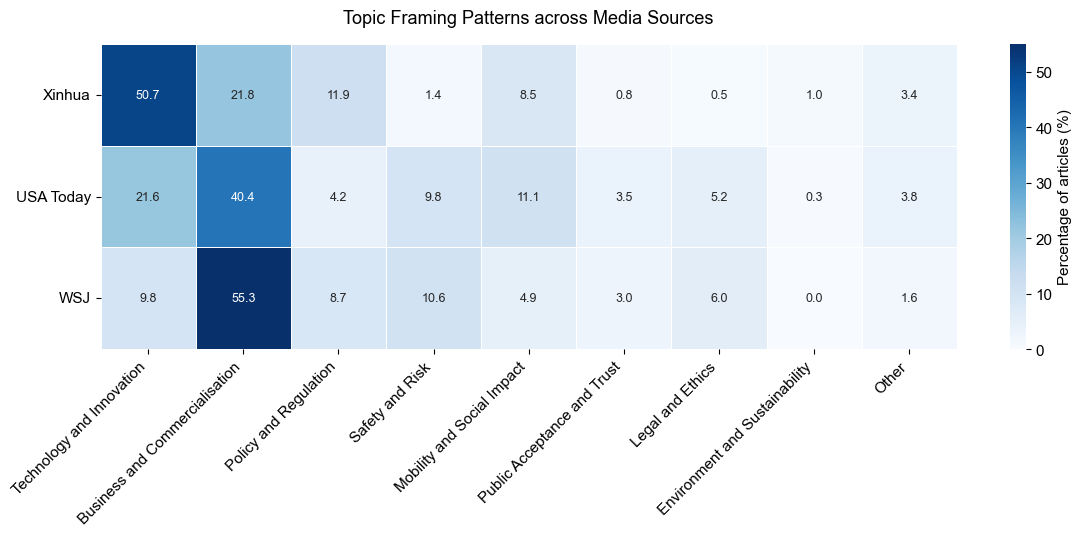

In [27]:
# ============================================================
# Figure 5
# Topic framing heatmap by source
# Publication-style version
# ============================================================

import seaborn as sns


# ------------------------------------------------------------
# Calculate topic percentages
# ------------------------------------------------------------

source_topic = (
    df.groupby(
        ["source","topic"]
    )
    .size()
    .reset_index(name="count")
)


source_topic["percentage"] = (
    source_topic.groupby("source")["count"]
    .transform(
        lambda x:x/x.sum()*100
    )
)



heatmap_df = (
    source_topic
    .pivot(
        index="source",
        columns="topic",
        values="percentage"
    )
    .fillna(0)
)



# ------------------------------------------------------------
# Conceptual framing order
# ------------------------------------------------------------

topic_order_framing = [
    "Technology and Innovation",
    "Business and Commercialisation",
    "Policy and Regulation",
    "Safety and Risk",
    "Mobility and Social Impact",
    "Public Acceptance and Trust",
    "Legal and Ethics",
    "Environment and Sustainability",
    "Other"
]


heatmap_df = heatmap_df[
    topic_order_framing
]

# Source order

heatmap_df = heatmap_df.loc[
    [
        "Xinhua",
        "USA Today",
        "WSJ"
    ]
]



# ------------------------------------------------------------
# Plot
# ------------------------------------------------------------

plt.figure(
    figsize=(12,5.5)
)



ax = sns.heatmap(
    heatmap_df,
    annot=True,
    fmt=".1f",
    cmap="Blues",
    linewidths=0.5,
    vmin=0,
    vmax=55,
    cbar_kws={
        "label":"Percentage of articles (%)"
    },
    annot_kws={
        "fontsize":9
    }
)



plt.title(
    "Topic Framing Patterns across Media Sources",
    pad=15,
    fontsize=13
)



plt.xlabel(
    ""
)


plt.ylabel(
    ""
)



plt.xticks(
    rotation=45,
    ha="right"
)



plt.yticks(
    rotation=0
)



plt.tight_layout()



plt.savefig(
    "Figure5_topic_heatmap_publication.png",
    dpi=300,
    bbox_inches="tight"
)



plt.show()

/var/folders/b6/85x24w2d4ylbyt_d01shhwfh0000gn/T/ipykernel_73508/4118615877.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby(


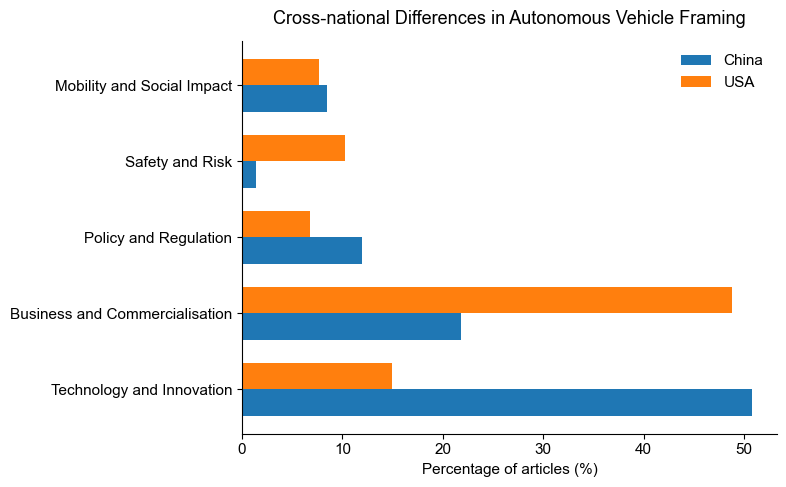

In [28]:
# ============================================================
# Figure 6
# China-US framing comparison
# ============================================================


country_topic = (
    df.groupby(
        ["country","topic"]
    )
    .size()
    .reset_index(name="count")
)



country_topic["percentage"] = (
    country_topic.groupby("country")["count"]
    .transform(
        lambda x:x/x.sum()*100
    )
)



compare_df = (
    country_topic
    .pivot(
        index="topic",
        columns="country",
        values="percentage"
    )
    .fillna(0)
)



major_topics = [
    "Technology and Innovation",
    "Business and Commercialisation",
    "Policy and Regulation",
    "Safety and Risk",
    "Mobility and Social Impact"
]


compare_df = (
    compare_df
    .loc[major_topics]
)



fig, ax = plt.subplots(
    figsize=(8,5)
)


y=np.arange(
    len(compare_df)
)


height=0.35



ax.barh(
    y-height/2,
    compare_df["China"],
    height,
    label="China"
)


ax.barh(
    y+height/2,
    compare_df["USA"],
    height,
    label="USA"
)

major_topics = [
    "Technology and Innovation",
    "Business and Commercialisation",
    "Policy and Regulation",
    "Safety and Risk",
    "Mobility and Social Impact"
]

ax.set_yticks(y)

ax.set_yticklabels(
    compare_df.index
)



ax.set_xlabel(
    "Percentage of articles (%)"
)



ax.set_title(
    "Cross-national Differences in Autonomous Vehicle Framing",
    pad=12
)



ax.legend(
    frameon=False
)



ax.spines["top"].set_visible(False)

ax.spines["right"].set_visible(False)



plt.tight_layout()



plt.savefig(
    "Figure6_country_framing_comparison.png",
    dpi=300,
    bbox_inches="tight"
)


plt.show()

In [36]:
print(compare_df.round(2))

country                         China    USA
topic                                       
Technology and Innovation       50.74  14.98
Business and Commercialisation  21.82  48.78
Policy and Regulation           11.95   6.73
Safety and Risk                  1.39  10.24
Mobility and Social Impact       8.48   7.65


In [13]:
# ============================================================
# Export topic summary tables
# ============================================================


topic_summary = (
    df["topic"]
    .value_counts()
    .reset_index()
)


topic_summary.columns = [
    "Topic",
    "Articles"
]


topic_summary.to_excel(
    "topic_summary.xlsx",
    index=False
)

In [33]:
# ============================================================
# Sentiment labels for cross-analysis
# ============================================================

sentiment_map = {
    -1: "Negative",
    0: "Neutral",
    1: "Positive"
}

df["sentiment_label"] = df["sentiment"].map(sentiment_map)

sentiment_order = [
    "Positive",
    "Neutral",
    "Negative"
]

df["sentiment_label"] = pd.Categorical(
    df["sentiment_label"],
    categories=sentiment_order,
    ordered=True
)

In [34]:
# ============================================================
# Topic × Sentiment: Overall
# ============================================================

topic_sentiment_counts = pd.crosstab(
    df["topic"],
    df["sentiment_label"]
)

topic_sentiment_pct = (
    pd.crosstab(
        df["topic"],
        df["sentiment_label"],
        normalize="index"
    ) * 100
)

topic_sentiment_overall = (
    topic_sentiment_pct
    .reindex(columns=sentiment_order)
    .round(1)
)

topic_sentiment_overall["n"] = topic_sentiment_counts.sum(axis=1)

topic_sentiment_overall

sentiment_label,Positive,Neutral,Negative,n
topic,,,,
Technology and Innovation,76.8,20.0,3.2,684
Safety and Risk,41.0,10.8,48.2,83
Policy and Regulation,59.9,28.6,11.5,182
Business and Commercialisation,69.5,20.8,9.6,571
Public Acceptance and Trust,60.0,10.0,30.0,30
Mobility and Social Impact,77.0,16.2,6.8,148
Environment and Sustainability,66.7,16.7,16.7,12
Legal and Ethics,44.2,16.3,39.5,43
Other,21.4,58.9,19.6,56


In [35]:
# ============================================================
# Country × Topic × Sentiment
# ============================================================

country_topic_counts = pd.crosstab(
    [df["country"], df["topic"]],
    df["sentiment_label"]
)

country_topic_pct = (
    pd.crosstab(
        [df["country"], df["topic"]],
        df["sentiment_label"],
        normalize="index"
    ) * 100
)

country_topic_sentiment = (
    country_topic_pct
    .reindex(columns=sentiment_order)
    .round(1)
)

country_topic_sentiment["n"] = country_topic_counts.sum(axis=1)

country_topic_sentiment

sentiment_label                         Positive  Neutral  Negative    n
country topic                                                           
China   Technology and Innovation           79.2     20.5       0.3  586
        Safety and Risk                     25.0      6.2      68.8   16
        Policy and Regulation               65.2     31.2       3.6  138
        Business and Commercialisation      76.6     22.6       0.8  252
        Public Acceptance and Trust         55.6     22.2      22.2    9
        Mobility and Social Impact          81.6     18.4       0.0   98
        Environment and Sustainability      72.7     18.2       9.1   11
        Legal and Ethics                    33.3     16.7      50.0    6
        Other                               25.6     66.7       7.7   39
USA     Technology and Innovation           62.2     17.3      20.4   98
        Safety and Risk                     44.8     11.9      43.3   67
        Policy and Regulation               43.2     20.5      36.4   44
        Business and Commercialisation      63.9     19.4      16.6  319
        Public Acceptance and Trust         61.9      4.8      33.3   21
        Mobility and Social Impact          68.0     12.0      20.0   50
        Environment and Sustainability       0.0      0.0     100.0    1
        Legal and Ethics                    45.9     16.2      37.8   37
        Other                               11.8     41.2      47.1   17